In [2]:
from PIL import Image
import numpy as np 
import matplotlib.pyplot as plt


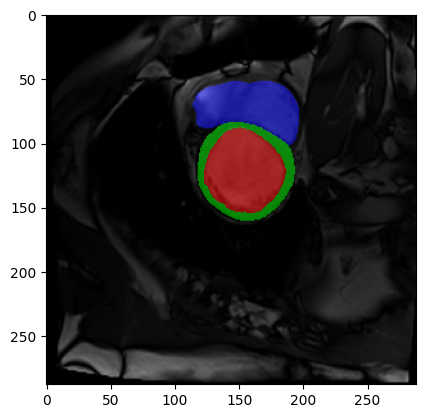

In [31]:
pred_img_path = "/storage/zhipengdeng/data/segmentation/cardiac/fed_semi/client_1/data/A0S9V9/img_vis/result/fl_cardiac_fixmatch_labeled_[2, 3, 4]_unseen_1_round_95_client_1/3_0_dice_0.9328.png"
original_img_path = "/storage/zhipengdeng/data/segmentation/cardiac/fed_semi/client_1/data/A0S9V9/img_vis/3_0.png"
pred_vis = Image.open(pred_img_path)
original_img_path = Image.open(original_img_path)
pred_vis_np = np.array(pred_vis).astype(np.int32)
original_img_np = np.array(original_img_path).astype(np.int32)

pred_mask = (pred_vis_np * 2) - original_img_np

pred_mask[pred_mask==-1]=0
pred_mask[pred_mask==254]=255
pred_mask[pred_mask==1]=0
pred_mask[pred_mask==256]=255



new_pred_img = np.zeros_like(pred_mask)

colors_to_replace = {
    (0, 255, 0): (255, 0, 0),
    (0, 0, 255): (0, 255, 0),
    (255, 255, 0): (0, 0, 255)
}

for old_color, new_color in colors_to_replace.items():
    mask = np.all(pred_mask == old_color, axis=-1)
    new_pred_img[mask] = new_color

new_pred_img = ((new_pred_img + original_img_np)* (0.5,0.5,0.5)).astype(np.uint8)

# show pred_mask
plt.imshow(new_pred_img)
plt.show()

color_list = [(255,0,0),(0,255,0),(0,0,255),(255,255,0),(255,0,255)]


In [29]:
unique_colors = np.unique(pred_mask.reshape(-1, pred_mask.shape[2]), axis=0)
print('Unique colors in pred_mask:', unique_colors)

Unique colors in pred_mask: [[  0   0 255]
 [  0 255   0]
 [255   0   0]
 [255 255   0]]


array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)